# RAG Result Check Notebook

이 노트북은 연인 갈등 대응 RAG 프로젝트의 **결과 확인용** 노트북입니다.

주요 확인 대상:
- retrieval 비교 결과
- retrieval 요약 지표 및 시각화
- failure cases 확인
- baseline vs RAG 정성 비교 결과 확인

실행용 파이프라인은 `.py` 파일에서 담당하고, 이 노트북은 **결과를 읽고 해석하는 용도**로 사용합니다.

## 1. 라이브러리 import 및 경로 설정

이 셀은 결과 CSV와 이미지 파일이 저장된 `data/processed` 경로를 잡는 역할을 합니다.

확인 파일:
- `retrieval_compare_results.csv`
- `retrieval_evaluation_summary.csv`
- `retrieval_failure_cases.csv`
- `baseline_vs_rag_results.csv`

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().resolve().parents[0]
PROCESSED_DATA_DIR = BASE_DIR / 'data' / 'processed'

retrieval_compare_path = PROCESSED_DATA_DIR / 'retrieval_compare_results.csv'
retrieval_summary_path = PROCESSED_DATA_DIR / 'retrieval_evaluation_summary.csv'
failure_cases_path = PROCESSED_DATA_DIR / 'retrieval_failure_cases.csv'
baseline_vs_rag_path = PROCESSED_DATA_DIR / 'baseline_vs_rag_results.csv'

print('BASE_DIR:', BASE_DIR)
print('PROCESSED_DATA_DIR:', PROCESSED_DATA_DIR)
print('retrieval_compare_exists:', retrieval_compare_path.exists())
print('retrieval_summary_exists:', retrieval_summary_path.exists())
print('failure_cases_exists:', failure_cases_path.exists())
print('baseline_vs_rag_exists:', baseline_vs_rag_path.exists())

BASE_DIR: C:\team_project\Andys_Data_Box
PROCESSED_DATA_DIR: C:\team_project\Andys_Data_Box\data\processed
retrieval_compare_exists: True
retrieval_summary_exists: True
failure_cases_exists: True
baseline_vs_rag_exists: True


## 2. Retrieval 원본 평가표 확인

이 셀은 `retrieval_compare_results.csv`를 불러와서 원본 평가표를 확인합니다.

주요 컬럼 의미:
- `is_relevant`: 질문 상황과 직접 관련이 있는지
- `emotion_match`: 질문 감정과 비슷한지
- `usable_for_reply`: 답변 추천 근거로 써먹기 좋은지
- `failure_type`: 실패 유형
- `failure_reason`: 실패 이유 한 줄 설명

In [2]:
retrieval_df = pd.read_csv(retrieval_compare_path)
retrieval_df.head(10)

,query,method,rank,dialogue_id,situation,speaker_emotion,risk_level,score,page_content_preview,is_relevant,emotion_match,usable_for_reply,failure_type,failure_reason
0,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,1,BE22028249,부모님이 결혼을 강요한다.,당황,normal,14.929180,관계: 연인\n핵심 상황: 부모님이 결혼을 강요한다.\n주요 감정: 당황\n청자 반...,0,0,0,situation_mismatch,"결혼 압박 상황으로, 내 말을 대충 듣는 서운함과 직접 연결되지 않음."
1,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,2,BE22024818,건강검진때문에 오늘 저녁은 금식인데 자꾸 먹고싶다.,상처,normal,14.004677,관계: 연인\n핵심 상황: 건강검진때문에 오늘 저녁은 금식인데 자꾸 먹고싶다.\n주...,0,1,0,situation_mismatch,상처 감정은 비슷하지만 금식/배고픔 상황이라 질문 맥락과 다름.
2,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,3,BE22012859,선물 받았지만 필요가 없어 다른 친구에게 주었다.,불안,normal,13.541890,관계: 연인\n핵심 상황: 선물 받았지만 필요가 없어 다른 친구에게 주었다.\n주요...,0,0,0,situation_mismatch,선물을 돌려준 갈등은 질문의 '말을 안 들어줌'과 거리가 큼.
3,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,1,BE22017733,내가 말을 하면 중간에 끊는 친구가 있다.,분노,normal,1.083559,관계: 연인\n핵심 상황: 내가 말을 하면 중간에 끊는 친구가 있다.\n주요 감정:...,1,1,1,NaN,NaN
4,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,2,BE22025748,친구가 절교하자며 모진 말을 했다.,상처,normal,1.085725,관계: 연인\n핵심 상황: 친구가 절교하자며 모진 말을 했다.\n주요 감정: 상처\...,0,1,0,situation_mismatch,상처 감정은 맞지만 절교 발언은 갈등 강도와 상황이 다름.
5,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,3,BE22026016,자전거를 타다가 벽에 부딪쳤다.,상처,normal,1.086802,관계: 연인\n핵심 상황: 자전거를 타다가 벽에 부딪쳤다.\n주요 감정: 상처\n청...,0,1,0,situation_mismatch,상처 감정은 있으나 사고/여행 맥락으로 답변 추천에 활용하기 어려움.
6,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,1,BE22028249,부모님이 결혼을 강요한다.,당황,normal,0.016393,관계: 연인\n핵심 상황: 부모님이 결혼을 강요한다.\n주요 감정: 당황\n청자 반...,0,0,0,situation_mismatch,결혼 압박 상황으로 질문과 직접 관련 없음.
7,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,2,BE22017733,내가 말을 하면 중간에 끊는 친구가 있다.,분노,normal,0.016393,관계: 연인\n핵심 상황: 내가 말을 하면 중간에 끊는 친구가 있다.\n주요 감정:...,1,1,1,NaN,NaN
8,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,3,BE22024818,건강검진때문에 오늘 저녁은 금식인데 자꾸 먹고싶다.,상처,normal,0.016129,관계: 연인\n핵심 상황: 건강검진때문에 오늘 저녁은 금식인데 자꾸 먹고싶다.\n주...,0,1,0,situation_mismatch,감정은 유사하지만 금식 상황이라 갈등 대화용 사례로 부적절함.
9,내가 힘들다고 했는데 공감 없이 넘어가서 속상해.,bm25,1,BE22007996,"20살 암 선고를 받은 날, 창밖을 보니 날리는 저 눈들처럼 아무 생각이 없었으면 ...",슬픔,high,12.157247,"관계: 연인\n핵심 상황: 20살 암 선고를 받은 날, 창밖을 보니 날리는 저 눈들...",0,1,0,risk_mismatch,슬픔 감정은 맞지만 암 선고라는 고위험 상황으로 일반적인 공감 부족 사례와 다름.


## 3. Retrieval 평가 컬럼만 집중 확인

이 셀은 수동으로 채운 평가값과 실패 분석 컬럼만 따로 확인하기 위한 셀입니다.
행별로 평가가 잘 들어갔는지 빠르게 볼 수 있습니다.

In [3]:
retrieval_df[
    [
        'query', 'method', 'rank',
        'is_relevant', 'emotion_match', 'usable_for_reply',
        'failure_type', 'failure_reason'
    ]
].head(20)

,query,method,rank,is_relevant,emotion_match,usable_for_reply,failure_type,failure_reason
0,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,1,0,0,0,situation_mismatch,"결혼 압박 상황으로, 내 말을 대충 듣는 서운함과 직접 연결되지 않음."
1,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,2,0,1,0,situation_mismatch,상처 감정은 비슷하지만 금식/배고픔 상황이라 질문 맥락과 다름.
2,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,3,0,0,0,situation_mismatch,선물을 돌려준 갈등은 질문의 '말을 안 들어줌'과 거리가 큼.
3,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,1,1,1,1,NaN,NaN
4,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,2,0,1,0,situation_mismatch,상처 감정은 맞지만 절교 발언은 갈등 강도와 상황이 다름.
5,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,3,0,1,0,situation_mismatch,상처 감정은 있으나 사고/여행 맥락으로 답변 추천에 활용하기 어려움.
6,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,1,0,0,0,situation_mismatch,결혼 압박 상황으로 질문과 직접 관련 없음.
7,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,2,1,1,1,NaN,NaN
8,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,3,0,1,0,situation_mismatch,감정은 유사하지만 금식 상황이라 갈등 대화용 사례로 부적절함.
9,내가 힘들다고 했는데 공감 없이 넘어가서 속상해.,bm25,1,0,1,0,risk_mismatch,슬픔 감정은 맞지만 암 선고라는 고위험 상황으로 일반적인 공감 부족 사례와 다름.


## 4. Retrieval 방식별 개수 확인

이 셀은 BM25, Dense, RRF 결과가 고르게 들어갔는지 확인하는 용도입니다.
보통 질문 수 × top-k 기준으로 비슷한 개수가 나와야 자연스럽습니다.

In [4]:
retrieval_df['method'].value_counts()

method
bm25     21
dense    21
rrf      21
Name: count, dtype: int64

## 5. Retrieval 요약 지표 확인

이 셀은 `retrieval_evaluation_summary.csv`를 불러와서
BM25 / Dense / RRF 중 어떤 방식이 더 좋았는지 확인하는 셀입니다.

주요 확인 포인트:
- `overall_mean`이 가장 높은 방식
- `is_relevant`, `emotion_match`, `usable_for_reply` 중 어느 항목이 강한지

In [5]:
summary_df = pd.read_csv(retrieval_summary_path)
summary_df

,method,is_relevant,emotion_match,usable_for_reply,overall_mean
0,bm25,0.285714,0.809524,0.285714,0.460317
1,dense,0.142857,0.761905,0.142857,0.349206
2,rrf,0.190476,0.809524,0.190476,0.396825


## 6. Retrieval 요약 시각화

이 셀은 방식별 평균 점수를 막대그래프로 확인하는 셀입니다.
발표 전 또는 결과 해석 전에 가장 먼저 보기 좋은 셀입니다.

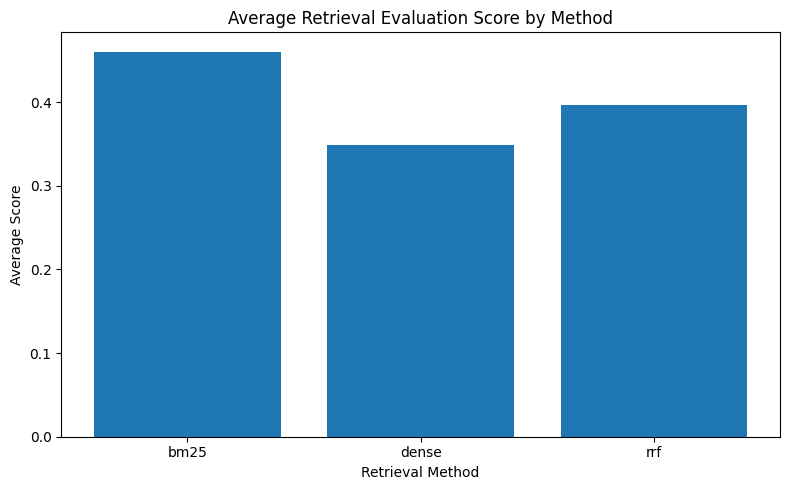

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df['method'], summary_df['overall_mean'])
plt.xlabel('Retrieval Method')
plt.ylabel('Average Score')
plt.title('Average Retrieval Evaluation Score by Method')
plt.tight_layout()
plt.show()

## 7. Failure cases 확인

이 셀은 retrieval 실패 사례만 모아둔 `retrieval_failure_cases.csv`를 확인하는 셀입니다.

주로 볼 것:
- 어떤 질문에서 실패했는지
- `failure_type`이 어떤 유형인지
- `failure_reason`이 납득 가능한지

In [7]:
failure_df = pd.read_csv(failure_cases_path)
failure_df

,query,method,rank,dialogue_id,situation,speaker_emotion,risk_level,score,page_content_preview,is_relevant,emotion_match,usable_for_reply,failure_type,failure_reason,failure_score
0,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,1,BE22028249,부모님이 결혼을 강요한다.,당황,normal,14.929180,관계: 연인\n핵심 상황: 부모님이 결혼을 강요한다.\n주요 감정: 당황\n청자 반...,0,0,0,situation_mismatch,"결혼 압박 상황으로, 내 말을 대충 듣는 서운함과 직접 연결되지 않음.",0
1,내가 힘들다고 했는데 공감 없이 넘어가서 속상해.,bm25,2,BE22018481,약속 시간에 늦고 오히려 큰 소리다.,분노,normal,12.026734,관계: 연인\n핵심 상황: 약속 시간에 늦고 오히려 큰 소리다.\n주요 감정: 분노...,0,0,0,situation_mismatch,사과 없이 큰소리 친 상황은 질문의 '공감 없이 넘어감'과 다름.,0
2,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,3,BE22012859,선물 받았지만 필요가 없어 다른 친구에게 주었다.,불안,normal,13.541890,관계: 연인\n핵심 상황: 선물 받았지만 필요가 없어 다른 친구에게 주었다.\n주요...,0,0,0,situation_mismatch,선물을 돌려준 갈등은 질문의 '말을 안 들어줌'과 거리가 큼.,0
3,내가 힘들다고 했는데 공감 없이 넘어가서 속상해.,bm25,3,BE22021512,엔진 오일을 교환하러 갔다가 브레이크까지 교체했다.,분노,normal,11.928179,관계: 연인\n핵심 상황: 엔진 오일을 교환하러 갔다가 브레이크까지 교체했다.\n주...,0,0,0,situation_mismatch,돈을 과다 지출한 억울함 사례로 질문 맥락과 다름.,0
4,다투고 나서 어색한데 먼저 뭐라고 보내야 할지 모르겠어.,dense,1,BE22002956,차를 운전하려고 보니 차 키를 집에 두고 왔다.,분노,normal,1.282214,관계: 연인\n핵심 상황: 차를 운전하려고 보니 차 키를 집에 두고 왔다.\n주요 ...,0,0,0,situation_mismatch,실수로 인한 짜증 상황으로 화해 메시지 고민과 무관함.,0
5,사소한 말다툼이 반복돼서 지쳐.,dense,1,BE22003465,한번 갔던 곳을 다시 방문해도 길을 찾는 게 어렵다.,불안,normal,1.385022,관계: 연인\n핵심 상황: 한번 갔던 곳을 다시 방문해도 길을 찾는 게 어렵다.\n...,0,0,0,situation_mismatch,길 찾기 불안 문제로 반복 말다툼과 무관함.,0
6,상대가 자꾸 장난처럼 넘겨서 진지하게 대화하고 싶어.,dense,2,BE22008945,가게 월세를 못 낸 지 세 달째다.,불안,normal,1.178485,관계: 연인\n핵심 상황: 가게 월세를 못 낸 지 세 달째다.\n주요 감정: 불안\...,0,0,0,situation_mismatch,월세 문제로 불안한 상황이라 질문과 직접 관련 없음.,0
7,다투고 나서 어색한데 먼저 뭐라고 보내야 할지 모르겠어.,dense,2,BE22021006,여행지에사 만나기로 한 가이드가 보이지 않는다.,불안,normal,1.286209,관계: 연인\n핵심 상황: 여행지에사 만나기로 한 가이드가 보이지 않는다.\n주요 ...,0,0,0,situation_mismatch,불안한 대기 상황으로 다툼 뒤 어색함과 다름.,0
8,다투고 나서 어색한데 먼저 뭐라고 보내야 할지 모르겠어.,dense,3,BE22017269,가로등이 꺼진 골목이 오늘따라 더 신경이 쓰인다.,불안,normal,1.330308,관계: 연인\n핵심 상황: 가로등이 꺼진 골목이 오늘따라 더 신경이 쓰인다.\n주요...,0,0,0,situation_mismatch,불안한 귀가 상황으로 질문에 활용하기 어려움.,0
9,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,1,BE22028249,부모님이 결혼을 강요한다.,당황,normal,0.016393,관계: 연인\n핵심 상황: 부모님이 결혼을 강요한다.\n주요 감정: 당황\n청자 반...,0,0,0,situation_mismatch,결혼 압박 상황으로 질문과 직접 관련 없음.,0


## 8. Failure type 분포 확인

이 셀은 어떤 실패 유형이 자주 나오는지 확인하는 셀입니다.
예를 들어 `situation_mismatch`가 많다면 상황 적합도가 retrieval의 핵심 문제일 가능성이 큽니다.

In [8]:
if 'failure_type' in failure_df.columns:
    display(failure_df['failure_type'].value_counts(dropna=False))
else:
    print('failure_type 컬럼이 없습니다.')

failure_type
situation_mismatch    10
Name: count, dtype: int64

## 9. 특정 질문별 retrieval 결과 확인

이 셀은 질문 하나를 골라 BM25 / Dense / RRF 결과를 나란히 비교하는 셀입니다.
발표 때 예시를 뽑거나, 어느 방식이 왜 잘/못 맞았는지 확인할 때 유용합니다.

In [9]:
target_query = retrieval_df['query'].iloc[0]
print('target_query:', target_query)
retrieval_df[retrieval_df['query'] == target_query].sort_values(by=['method', 'rank'])

target_query: 남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?


,query,method,rank,dialogue_id,situation,speaker_emotion,risk_level,score,page_content_preview,is_relevant,emotion_match,usable_for_reply,failure_type,failure_reason
0,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,1,BE22028249,부모님이 결혼을 강요한다.,당황,normal,14.929180,관계: 연인\n핵심 상황: 부모님이 결혼을 강요한다.\n주요 감정: 당황\n청자 반...,0,0,0,situation_mismatch,"결혼 압박 상황으로, 내 말을 대충 듣는 서운함과 직접 연결되지 않음."
1,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,2,BE22024818,건강검진때문에 오늘 저녁은 금식인데 자꾸 먹고싶다.,상처,normal,14.004677,관계: 연인\n핵심 상황: 건강검진때문에 오늘 저녁은 금식인데 자꾸 먹고싶다.\n주...,0,1,0,situation_mismatch,상처 감정은 비슷하지만 금식/배고픔 상황이라 질문 맥락과 다름.
2,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,bm25,3,BE22012859,선물 받았지만 필요가 없어 다른 친구에게 주었다.,불안,normal,13.541890,관계: 연인\n핵심 상황: 선물 받았지만 필요가 없어 다른 친구에게 주었다.\n주요...,0,0,0,situation_mismatch,선물을 돌려준 갈등은 질문의 '말을 안 들어줌'과 거리가 큼.
3,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,1,BE22017733,내가 말을 하면 중간에 끊는 친구가 있다.,분노,normal,1.083559,관계: 연인\n핵심 상황: 내가 말을 하면 중간에 끊는 친구가 있다.\n주요 감정:...,1,1,1,NaN,NaN
4,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,2,BE22025748,친구가 절교하자며 모진 말을 했다.,상처,normal,1.085725,관계: 연인\n핵심 상황: 친구가 절교하자며 모진 말을 했다.\n주요 감정: 상처\...,0,1,0,situation_mismatch,상처 감정은 맞지만 절교 발언은 갈등 강도와 상황이 다름.
5,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,dense,3,BE22026016,자전거를 타다가 벽에 부딪쳤다.,상처,normal,1.086802,관계: 연인\n핵심 상황: 자전거를 타다가 벽에 부딪쳤다.\n주요 감정: 상처\n청...,0,1,0,situation_mismatch,상처 감정은 있으나 사고/여행 맥락으로 답변 추천에 활용하기 어려움.
6,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,1,BE22028249,부모님이 결혼을 강요한다.,당황,normal,0.016393,관계: 연인\n핵심 상황: 부모님이 결혼을 강요한다.\n주요 감정: 당황\n청자 반...,0,0,0,situation_mismatch,결혼 압박 상황으로 질문과 직접 관련 없음.
7,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,2,BE22017733,내가 말을 하면 중간에 끊는 친구가 있다.,분노,normal,0.016393,관계: 연인\n핵심 상황: 내가 말을 하면 중간에 끊는 친구가 있다.\n주요 감정:...,1,1,1,NaN,NaN
8,남자친구가 내 말을 대충 듣는 것 같아서 서운해. 어떻게 말하면 좋을까?,rrf,3,BE22024818,건강검진때문에 오늘 저녁은 금식인데 자꾸 먹고싶다.,상처,normal,0.016129,관계: 연인\n핵심 상황: 건강검진때문에 오늘 저녁은 금식인데 자꾸 먹고싶다.\n주...,0,1,0,situation_mismatch,감정은 유사하지만 금식 상황이라 갈등 대화용 사례로 부적절함.


## 10. Baseline vs RAG 비교 결과 확인

이 셀은 `baseline_vs_rag_results.csv`를 불러와서
baseline 답변과 RAG 답변의 정성 비교 결과를 확인하는 셀입니다.

In [10]:
compare_df = pd.read_csv(baseline_vs_rag_path)
compare_df

,question,baseline_answer,rag_answer,empathy_better,specificity_better,safer_expression,more_usable,final_preference,notes
0,남자친구가 내 말을 제대로 안 들어주는 것 같아서 서운해. 어떻게 보내면 좋을까?,[추천 답변 1] \n내가 하는 말을 좀 더 잘 들어줬으면 좋겠어. 네 생각도 궁...,[상황 요약] \n남자친구가 내 말을 제대로 들어주지 않는 것 같아 서운함을 느끼...,rag,rag,same,rag,rag,RAG가 감정 라벨과 피해야 할 표현/대체 표현까지 제시해 더 풍부함. 다만 '신용...
1,내가 힘들다고 했는데 공감 없이 넘어가서 속상해.,[추천 답변 1] \n내가 힘들다고 했을 때 조금 더 들어주면 좋겠어. 네가 내 ...,[상황 요약] \n연인에게 힘들다고 표현했지만 공감받지 못해 속상한 상황입니다.\...,rag,rag,same,rag,rag,"RAG가 공감 부족 상황을 더 직접적으로 반영하고, 감정 표현과 대체 표현이 구체적..."
2,사소한 말다툼이 반복돼서 지쳐. 뭐라고 보내야 할까?,[추천 답변 1] \n요즘 자꾸 작은 일로 다투게 돼서 나도 힘들어. 우리 조금만...,[상황 요약] \n연인 관계에서 누나와 매형 사이에 이혼 이야기가 나와서 마음이 ...,same,baseline,same,baseline,baseline,RAG가 질문에 없는 '누나/매형/이혼' 맥락을 끌어와 상황 적합성이 떨어짐. ba...


## 11. Baseline vs RAG 정성 평가 컬럼만 확인

이 셀은 어떤 질문에서 baseline이 더 나았는지, RAG가 더 나았는지를
빠르게 파악하기 위한 셀입니다.

주요 컬럼 의미:
- `empathy_better`: 공감 표현이 더 좋은 쪽
- `specificity_better`: 상황 맞춤형으로 더 구체적인 쪽
- `safer_expression`: 덜 공격적이고 안전한 표현인 쪽
- `more_usable`: 실제 복붙해서 쓰기 더 좋은 쪽
- `final_preference`: 전체적으로 더 선호되는 쪽

In [11]:
compare_df[
    [
        'question',
        'empathy_better',
        'specificity_better',
        'safer_expression',
        'more_usable',
        'final_preference',
        'notes'
    ]
]

,question,empathy_better,specificity_better,safer_expression,more_usable,final_preference,notes
0,남자친구가 내 말을 제대로 안 들어주는 것 같아서 서운해. 어떻게 보내면 좋을까?,rag,rag,same,rag,rag,RAG가 감정 라벨과 피해야 할 표현/대체 표현까지 제시해 더 풍부함. 다만 '신용...
1,내가 힘들다고 했는데 공감 없이 넘어가서 속상해.,rag,rag,same,rag,rag,"RAG가 공감 부족 상황을 더 직접적으로 반영하고, 감정 표현과 대체 표현이 구체적..."
2,사소한 말다툼이 반복돼서 지쳐. 뭐라고 보내야 할까?,same,baseline,same,baseline,baseline,RAG가 질문에 없는 '누나/매형/이혼' 맥락을 끌어와 상황 적합성이 떨어짐. ba...


## 12. 질문별 baseline / RAG 답변 원문 보기

이 셀은 실제 답변 내용을 질문별로 길게 출력하는 셀입니다.
정성 비교를 할 때 가장 실질적으로 도움이 됩니다.

In [12]:
for i, row in compare_df.iterrows():
    print('=' * 100)
    print(f'[질문 {i+1}]')
    print(row['question'])
    print('\n[Baseline]')
    print(row['baseline_answer'])
    print('\n[RAG]')
    print(row['rag_answer'])
    print('\n[Final Preference]')
    print(row.get('final_preference', ''))
    print('\n[Notes]')
    print(row.get('notes', ''))
    print()

[질문 1]
남자친구가 내 말을 제대로 안 들어주는 것 같아서 서운해. 어떻게 보내면 좋을까?

[Baseline]
[추천 답변 1]  
내가 하는 말을 좀 더 잘 들어줬으면 좋겠어. 네 생각도 궁금하고, 서로 더 잘 이해하고 싶어.

[추천 답변 2]  
가끔 내 얘기 들어주는 게 부족한 것 같아서 서운해. 조금만 더 신경 써줄 수 있을까?

[RAG]
[상황 요약]  
남자친구가 내 말을 제대로 들어주지 않는 것 같아 서운함을 느끼고 있음. 신용카드 분실 신고 문제로 상처받은 상태.

[감정]  
슬픔, 서운함, 상처

[위험도]  
normal

[추천 답변 1]  
"내가 이렇게 말할 때 좀 더 귀 기울여줬으면 좋겠어. 네가 내 마음을 이해해주면 훨씬 힘이 될 것 같아."

[추천 답변 2]  
"내가 서운한 마음이 있어서 그래. 네가 내 얘기를 잘 들어주면 우리 관계가 더 좋아질 것 같아."

[피해야 할 표현]  
- "너는 항상 내 말을 안 들어."  
- "왜 내 마음을 몰라주는 거야?"  
- "네가 무심해서 상처받았어."

[대체 표현]  
- "가끔 내 얘기를 잘 못 듣는 것 같아서 속상해."  
- "내 마음을 알아주면 좋겠어."  
- "네가 조금만 더 신경 써주면 좋겠어."

[Final Preference]
rag

[Notes]
RAG가 감정 라벨과 피해야 할 표현/대체 표현까지 제시해 더 풍부함. 다만 '신용카드 분실 신고' 맥락은 질문에 직접 없어서 약간 과잉 추론.

[질문 2]
내가 힘들다고 했는데 공감 없이 넘어가서 속상해.

[Baseline]
[추천 답변 1]  
내가 힘들다고 했을 때 조금 더 들어주면 좋겠어. 네가 내 마음을 이해해주면 정말 힘이 될 것 같아.

[추천 답변 2]  
내가 속상한 마음을 알아줬으면 해. 함께 이야기하면서 서로 더 잘 이해할 수 있으면 좋겠어.

[RAG]
[상황 요약]  
연인에게 힘들다고 표현했지만 공감받지 못해 속상한 상황입니다.

[감정]  
속상함, 서운함

[위험도]  
no

## 13. 최종 해석

- retrieval best method:
  이번 실험에서는 BM25가 가장 높은 overall_mean을 기록해 가장 안정적인 retrieval 방식으로 나타났다.
  현재 질문들이 비교적 직접적인 표현을 포함하고 있어 dense 기반보다 키워드 매칭 기반 BM25가 더 잘 작동한 것으로 보인다.

- most common failure type:
  failure_type은 대부분 situation_mismatch로 나타났다.
  이는 감정은 비슷한 사례를 찾더라도, 실제 갈등 상황 맥락까지 정확히 맞는 사례를 찾는 데에는 한계가 있음을 의미한다.

- baseline vs rag summary:
  baseline과 RAG를 비교했을 때 일부 질문에서는 RAG가 더 공감적이고 구체적인 답변을 생성했다.
  다만 retrieval이 잘못된 사례를 가져오면 질문에 없는 맥락이 섞여 최종 답변 품질이 떨어지는 경우도 확인되었다.
  따라서 RAG는 잠재력은 있지만 retrieval 품질에 크게 영향을 받는 구조라고 볼 수 있다.

- next improvement:
  다음 단계에서는 rag_text를 감정보다 상황 중심으로 다시 구성하고,
  retrieval 후처리에서 연인 관계 및 상황 적합도 기준의 필터링을 추가할 필요가 있다.
  또한 프롬프트에 질문에 없는 구체적 사건이나 관계를 추가하지 말라는 제약을 더 강하게 넣어 생성 안정성을 높이는 것이 중요하다.